In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import sys
import random
import re
import importlib

BASE_DIR = Path('/content/drive/MyDrive/먼작귀')

COMMON_DIR = BASE_DIR / 'synthetic_scenarios'
FRONT_DIR = COMMON_DIR / 'front'

candidate_project_dirs = [
    Path.cwd(),
    COMMON_DIR,
    FRONT_DIR,
]

candidate_project_dirs += [
    p.parent for p in Path('/content/drive').glob(
        '.shortcut-targets-by-id/*/*/synthetic_scenarios/front/shelf_synthetic_common.py'
    )
]

PROJECT_DIR = None
for d in candidate_project_dirs:
    if (d / 'shelf_synthetic_common.py').exists():
        PROJECT_DIR = d
        break

if PROJECT_DIR is None:
    raise FileNotFoundError(
        'shelf_synthetic_common.py 파일을 찾지 못했습니다. '
        '노트북(.ipynb)과 shelf_synthetic_common.py를 같은 폴더에 두거나, '
        'PROJECT_DIR를 실제 파일 위치로 수정해주세요.'
    )

LABELER_DIR = COMMON_DIR

if not (LABELER_DIR / 'synthetic_label_exporter.py').exists():
    raise FileNotFoundError(
        f'synthetic_label_exporter.py 파일을 찾지 못했습니다: {LABELER_DIR}'
    )

# shelf_synthetic_common.py는 front 폴더에서,
# synthetic_label_exporter.py는 synthetic_scenarios 공통 폴더에서 import
for p in [PROJECT_DIR, LABELER_DIR]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

print('공통 py 파일 위치:', PROJECT_DIR / 'shelf_synthetic_common.py')
print('라벨 exporter 위치:', LABELER_DIR / 'synthetic_label_exporter.py')
print('BASE_DIR:', BASE_DIR)

import shelf_synthetic_common as synth
import synthetic_label_exporter as labeler

importlib.reload(synth)
importlib.reload(labeler)

ctx = synth.create_synthetic_context(
    base_dir=BASE_DIR,
    background_name='선반이미지_정면.png',
    seed=42,
)

print("shelf_lip_polygons 개수:", len(ctx.get("shelf_lip_polygons", [])))
print("context 생성 완료")

공통 py 파일 위치: /content/drive/MyDrive/먼작귀/synthetic_scenarios/front/shelf_synthetic_common.py
라벨 exporter 위치: /content/drive/MyDrive/먼작귀/synthetic_scenarios/synthetic_label_exporter.py
BASE_DIR: /content/drive/MyDrive/먼작귀
shelf_lip_polygons 개수: 5
context 생성 완료


S5 정면 생성 중:   0%|          | 0/240 [00:00<?, ?img/s]

[20/240] 완료 | 최근 파일: synthetic_s5_020.png | 오진열 대상: 0개 | ctx: 0.16초 | render: 7.9초 | label: 1.66초 | 평균: 12.60초/장 | 예상 남은 시간: 46.2분
[40/240] 완료 | 최근 파일: synthetic_s5_040.png | 오진열 대상: 3개 | ctx: 0.16초 | render: 8.55초 | label: 1.66초 | 평균: 12.17초/장 | 예상 남은 시간: 40.6분
[60/240] 완료 | 최근 파일: synthetic_s5_060.png | 오진열 대상: 1개 | ctx: 0.16초 | render: 7.89초 | label: 1.71초 | 평균: 12.21초/장 | 예상 남은 시간: 36.6분
[80/240] 완료 | 최근 파일: synthetic_s5_080.png | 오진열 대상: 2개 | ctx: 0.15초 | render: 8.08초 | label: 1.67초 | 평균: 12.06초/장 | 예상 남은 시간: 32.2분
[100/240] 완료 | 최근 파일: synthetic_s5_100.png | 오진열 대상: 0개 | ctx: 0.16초 | render: 8.06초 | label: 1.66초 | 평균: 12.00초/장 | 예상 남은 시간: 28.0분
[120/240] 완료 | 최근 파일: synthetic_s5_120.png | 오진열 대상: 3개 | ctx: 0.16초 | render: 8.39초 | label: 1.67초 | 평균: 11.92초/장 | 예상 남은 시간: 23.8분
[140/240] 완료 | 최근 파일: synthetic_s5_140.png | 오진열 대상: 4개 | ctx: 0.16초 | render: 8.55초 | label: 1.66초 | 평균: 11.94초/장 | 예상 남은 시간: 19.9분
[160/240] 완료 | 최근 파일: synthetic_s5_160.png | 오진열 대상: 1개 | ctx: 0.16초 | ren

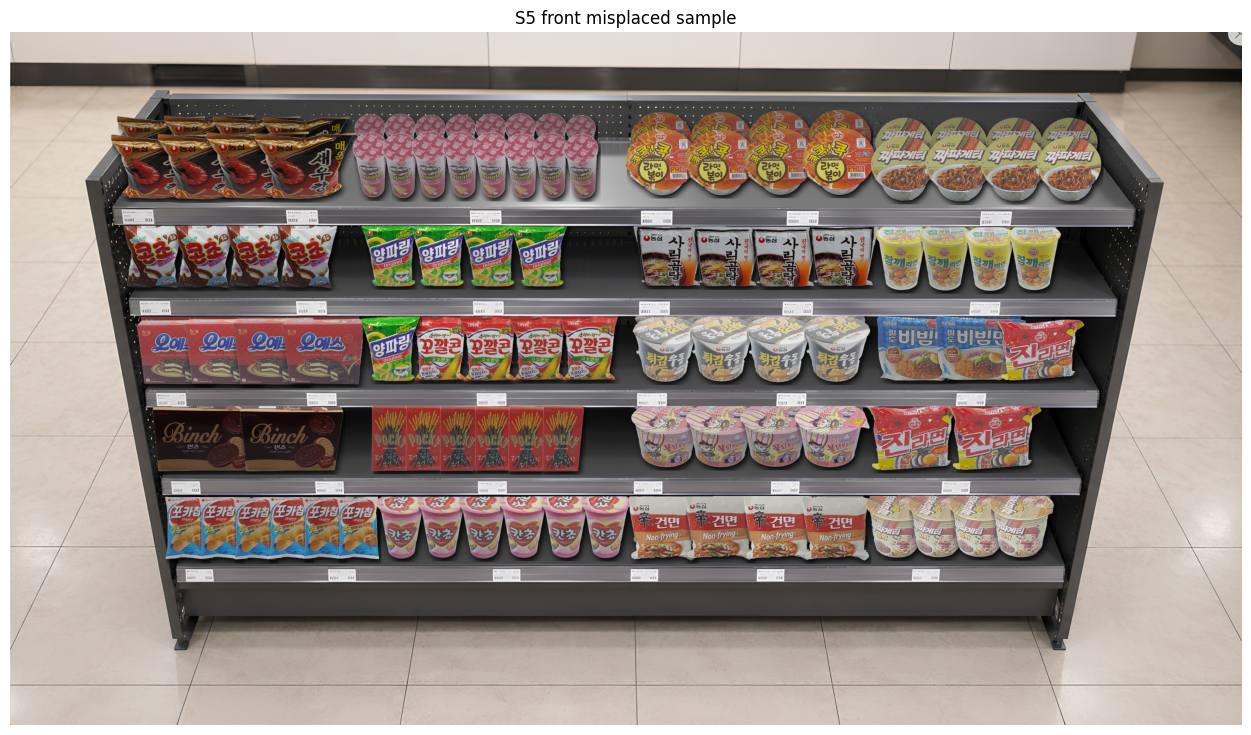

In [4]:
# S5 정면 합성 + 이미지/라벨 저장
from tqdm.auto import tqdm
import time
import random
import numpy as np
import re
from PIL import Image

SCENARIO_CODE = 'S5'
SCENARIO_NAME = '오진열'

NUM_IMAGES = 240
BASE_SEED = 550560

def get_next_start_index(image_dir, scenario_code):
    pattern = re.compile(rf'^synthetic_{scenario_code.lower()}_(\d{{3}})\.png$')
    max_num = 0

    for p in image_dir.glob(f'synthetic_{scenario_code.lower()}_*.png'):
        m = pattern.match(p.name)
        if m:
            max_num = max(max_num, int(m.group(1)))

    return max_num + 1


def sample_nonempty_subset(items, prob_range=(0.1, 0.4), keep_at_least_one_unselected=False):
    """
    개수를 직접 고정하지 않고, 매번 다른 확률로 subset을 랜덤 샘플링한다.
    """
    items = list(items)

    if len(items) == 0:
        return []

    p = random.uniform(*prob_range)
    selected = [x for x in items if random.random() < p]

    if not selected:
        selected = [random.choice(items)]

    if keep_at_least_one_unselected and len(items) > 1 and len(selected) == len(items):
        drop_one = random.choice(selected)
        selected = [x for x in selected if x != drop_one]

        if not selected:
            selected = [random.choice(items)]

    return selected


def get_resized_width_for_slot(product_dir, slot):
    """
    해당 slot에 상품을 붙였을 때의 예상 가로 크기를 계산한다.
    실제 합성 함수와 비슷하게 slot 높이를 기준으로 resize한 뒤 width를 계산한다.
    """
    product_path = synth.get_png_by_slot_view(
        product_dir=product_dir,
        slot=slot,
        image_type="s",
    )

    if product_path is None:
        return None

    img = Image.open(product_path).convert("RGBA")
    w, h = img.size

    if h <= 0:
        return None

    dynamic_scale = synth.get_scale_by_slot(slot)
    slot_height = slot["y2"] - slot["y1"]

    target_h = int(slot_height * dynamic_scale)
    resize_ratio = target_h / h
    resized_w = int(w * resize_ratio)

    return resized_w


def choose_wrong_item_by_width(all_items, target, slot, width_tolerance=0.10):
    """
    기준 상품과 '합성 후 예상 가로폭'이 비슷한 상품 중에서 오진열 후보를 선택한다.

    width_tolerance=0.10:
    기준 상품 width 대비 ±10% 범위 안에 드는 상품만 후보로 사용.
    """
    base_width = get_resized_width_for_slot(
        target["target_product_dir"],
        slot,
    )

    if base_width is None:
        return None

    candidates = []

    for item in all_items:
        if item["zone_id"] != target["zone_id"]:
            continue

        if item["product_dir"] == target["target_product_dir"]:
            continue

        wrong_width = get_resized_width_for_slot(
            item["product_dir"],
            slot,
        )

        if wrong_width is None:
            continue

        width_diff = abs(wrong_width - base_width) / base_width

        if width_diff <= width_tolerance:
            candidates.append(item)

    # 후보가 없으면 억지로 이상한 상품을 넣지 않음
    if not candidates:
        return None

    return random.choice(candidates)


def paste_single_wrong_product_at_index(
    result,
    base_product_dir,
    wrong_product_dir,
    slot,
    front_qty,
    misplaced_index,
):
    """
    S5 오진열 전용:
    - 기준 상품 배열의 position_index를 그대로 사용
    - 해당 위치 1개만 wrong_product로 붙임
    - wrong_product는 원본 비율 유지
    - wrong 상품이 너무 커지지 않도록 높이와 폭 제한 적용
    """
    base_product_path = synth.get_png_by_slot_view(
        product_dir=base_product_dir,
        slot=slot,
        image_type="s",
    )

    wrong_product_path = synth.get_png_by_slot_view(
        product_dir=wrong_product_dir,
        slot=slot,
        image_type="s",
    )

    if base_product_path is None or wrong_product_path is None:
        return None

    base_product = Image.open(base_product_path).convert("RGBA")
    wrong_product = Image.open(wrong_product_path).convert("RGBA")

    anchor_x = slot["anchor_x"]
    anchor_y = slot["anchor_y"]

    dynamic_scale = synth.get_scale_by_slot(slot)
    slot_height = slot["y2"] - slot["y1"]

    base_product_h = int(slot_height * dynamic_scale)
    base_ratio = base_product_h / base_product.height
    base_product_w = int(base_product.width * base_ratio)

    slot_left = slot["x1"]
    slot_right = slot["x2"]

    min_center_x = slot_left + base_product_w / 2
    max_center_x = slot_right - base_product_w / 2

    if max_center_x < min_center_x:
        max_width = max(20, slot_right - slot_left)
        shrink_ratio = max_width / base_product_w * 0.95

        base_product_w = int(base_product_w * shrink_ratio)
        base_product_h = int(base_product_h * shrink_ratio)

        min_center_x = slot_left + base_product_w / 2
        max_center_x = slot_right - base_product_w / 2

    start_center_x = max(anchor_x, min_center_x)
    start_center_x = min(start_center_x, max_center_x)

    if front_qty <= 1:
        step_x = 0
    else:
        default_overlap_ratio = 0.15
        default_step_x = base_product_w * (1 - default_overlap_ratio)
        available_center_width = max_center_x - start_center_x

        step_x = min(default_step_x, available_center_width / (front_qty - 1))
        step_x = max(0, step_x)

    center_x_list = [
        start_center_x + i * step_x
        for i in range(front_qty)
    ]

    if misplaced_index >= len(center_x_list):
        return None

    size_jitter = random.uniform(0.98, 1.02)

    # wrong 상품을 기준 상품 높이와 비슷하게 맞추되 과확대 방지
    target_h = int(base_product_h * size_jitter)

    wrong_w, wrong_h = wrong_product.size
    resize_ratio = target_h / wrong_h

    target_w = int(wrong_w * resize_ratio)

    if front_qty <= 1 or len(center_x_list) <= 1:
        item_cell_w = slot_right - slot_left
    else:
        item_cell_w = abs(center_x_list[1] - center_x_list[0])

    max_w_by_base = int(base_product_w * 1.50)
    max_w_by_cell = int(item_cell_w * 1.50)
    max_w_by_slot = int((slot_right - slot_left) / max(front_qty, 1) * 1.70)

    max_allowed_w = max(
        20,
        min(max_w_by_base, max_w_by_cell, max_w_by_slot)
    )

    if target_w > max_allowed_w:
        shrink = max_allowed_w / target_w
        target_w = int(target_w * shrink)
        target_h = int(target_h * shrink)

    min_allowed_h = int(base_product_h * 0.90)

    if target_h < min_allowed_h:
        grow = min_allowed_h / target_h
        grown_w = int(target_w * grow)
        grown_h = int(target_h * grow)

        if grown_w <= max_allowed_w:
            target_w = grown_w
            target_h = grown_h

    target_w = max(1, int(target_w))
    target_h = max(1, int(target_h))

    wrong_product = wrong_product.resize(
        (target_w, target_h),
        resample=Image.LANCZOS
    )

    wrong_product = synth.adjust_product_color(wrong_product)

    angle = random.uniform(-0.2, 0.2)
    wrong_product = wrong_product.rotate(
        angle,
        expand=True,
        resample=Image.BICUBIC
    )

    rotated_w, rotated_h = wrong_product.size

    item_anchor_x = center_x_list[misplaced_index]
    item_anchor_y = anchor_y

    paste_x = int(item_anchor_x - rotated_w / 2)
    paste_y = int(item_anchor_y - rotated_h)

    if paste_x < slot["x1"]:
        paste_x = slot["x1"]

    if paste_x + rotated_w > slot["x2"]:
        paste_x = slot["x2"] - rotated_w

    paste_x += random.randint(-1, 1)
    paste_y += random.randint(-1, 1)

    synth.add_shadow(result, wrong_product, paste_x, paste_y)
    result.paste(wrong_product, (paste_x, paste_y), wrong_product)

    wrong_product_id, wrong_product_name = synth.get_product_info_from_dir(
        wrong_product_dir
    )

    return {
        "bbox": [paste_x, paste_y, paste_x + rotated_w, paste_y + rotated_h],
        "source_png": str(wrong_product_path),
        "angle_info": synth.parse_png_info(wrong_product_path),
        "depth_row": "front",
        "position_index": misplaced_index,
        "is_misplaced_item": True,
        "wrong_product_id": str(wrong_product_id),
        "wrong_product_name": wrong_product_name,
    }


# ------------------------------------------------------------
# SAHI 기준 최종 라벨 저장 경로
# ------------------------------------------------------------

IMAGE_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'images' / 'front' / SCENARIO_CODE.lower()
PRODUCT_YOLO_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_yolo' / 'front' / SCENARIO_CODE.lower()
SHELF_LIP_YOLO_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_yolo_seg' / 'front' / SCENARIO_CODE.lower()
JSON_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_json' / 'front' / SCENARIO_CODE.lower()

for d in [IMAGE_DIR, PRODUCT_YOLO_DIR, SHELF_LIP_YOLO_DIR, JSON_DIR]:
    d.mkdir(parents=True, exist_ok=True)

start_idx = get_next_start_index(IMAGE_DIR, SCENARIO_CODE)

saved_paths = []
generation_logs = []
last_result = None
last_label_result = None

start_time = time.time()

pbar = tqdm(range(NUM_IMAGES), desc=f'{SCENARIO_CODE} 정면 생성 중', unit='img')

for image_idx in pbar:
    seed = BASE_SEED + image_idx

    random.seed(seed)
    np.random.seed(seed)

    if hasattr(synth, 'reset_random_seed'):
        synth.reset_random_seed(seed)

    # ------------------------------------------------------------
    # 1. 이미지마다 context 새로 생성
    # 중요:
    # create_synthetic_context 안에서 상품이 slot에 랜덤 배치되므로
    # 상품/위치가 매번 바뀌려면 반드시 루프 안에 있어야 함
    # ------------------------------------------------------------
    t_ctx0 = time.time()

    ctx_i = synth.create_synthetic_context(
        base_dir=BASE_DIR,
        background_name='선반이미지_정면.png',
        seed=seed,
    )

    t_ctx1 = time.time()

    # ------------------------------------------------------------
    # 2. S5 기본 데이터 준비
    # ------------------------------------------------------------
    all_items = synth.collect_slot_items(ctx_i)

    slot_plan = synth.make_normal_slot_plan(ctx_i)
    slot_ids = list(slot_plan.keys())

    selected_slot_ids = sample_nonempty_subset(
        slot_ids,
        prob_range=(0.04, 0.18)
    )

    misplaced_jobs = []

    s5_logs = []

    # ------------------------------------------------------------
    # 3. 선택된 슬롯에 오진열 적용
    # ------------------------------------------------------------
    for slot_id in selected_slot_ids:
        target = slot_plan[slot_id]

        front_qty = int(target.get('normal_front_qty', target.get('display_qty', 0)))
        back_qty = int(target.get('normal_back_qty', target.get('back_display_qty', front_qty)))

        if front_qty <= 0:
            continue

        # 한 슬롯에서 오진열은 상품 1개만 발생
        misplaced_index = random.randrange(front_qty)

        # 원본 로직 유지:
        # 실제 합성 예상 가로폭이 비슷한 상품 중에서 wrong 상품 선택
        wrong_item = choose_wrong_item_by_width(
            all_items=all_items,
            target=target,
            slot=target["slot"],
            width_tolerance=0.10,
        )

        if wrong_item is None:
            continue

        wrong_product_dir = wrong_item["product_dir"]
        wrong_product_id = wrong_item["product_id"]
        wrong_product_name = wrong_item["product_name"]

        base_width = get_resized_width_for_slot(
            target["target_product_dir"],
            target["slot"],
        )

        wrong_width = get_resized_width_for_slot(
            wrong_product_dir,
            target["slot"],
        )

        if base_width is not None and wrong_width is not None:
            width_diff = abs(wrong_width - base_width) / base_width
        else:
            width_diff = None

        target.update({
            'scenario_code': SCENARIO_CODE,
            'sub_scenario_code': SCENARIO_CODE,
            'scenario_name': SCENARIO_NAME,
            'action': 'misplaced_one_item',

            'list_up': True,
            'final_status': '확인 필요',
            'status_code': 'CHECK_REQUIRED',
            'status_label': '확인 필요',

            # 기준 상품은 유지하고, 오진열 위치 1개만 비워둔 뒤 wrong 상품을 따로 붙임
            'actual_product_dir': target['target_product_dir'],
            'actual_product_id': target['target_product_id'],
            'actual_product_name': target['target_product_name'],

            'display_qty': front_qty,
            'back_display_qty': back_qty,

            # 오진열 위치의 기준 앞줄 상품 제거
            'front_missing_indices': [misplaced_index],

            # 오진열 위치의 뒷줄 상품도 제거해서 뒤 상품이 비쳐 보이는 문제 완화
            'back_missing_indices': [misplaced_index],
            'back_visible_indices': None,

            # wrong 상품은 render 후 직접 붙임
            'extra_misplaced_items': [],

            # 상태/라벨용
            'is_misplaced': True,
            'is_front_depleted': False,
            'is_slot_empty': False,

            # 오진열은 결손이 아니라 확인 필요로 판단
            'front_missing_qty': 0,
            'back_missing_qty': 0,
            'missing_qty': 0,
            'missing_ratio': 0.0,
            'reduced_front_qty': front_qty,

            'target_column_index': None,

            # JSON/로그 확인용
            'misplaced_index': misplaced_index,
            'misplaced_product_id': str(wrong_product_id),
            'misplaced_product_name': wrong_product_name,
        })

        misplaced_jobs.append({
            'slot_id': slot_id,
            'slot': target['slot'],
            'front_qty': front_qty,
            'misplaced_index': misplaced_index,
            'base_product_dir': target['target_product_dir'],
            'wrong_product_dir': wrong_product_dir,
            'wrong_product_id': str(wrong_product_id),
            'wrong_product_name': wrong_product_name,
        })

        s5_logs.append({
            'slot_id': slot_id,
            'base_product_id': target['target_product_id'],
            'base_product_name': target['target_product_name'],
            'misplaced_index': misplaced_index,
            'wrong_product_id': str(wrong_product_id),
            'wrong_product_name': wrong_product_name,
            'base_width': base_width,
            'wrong_width': wrong_width,
            'width_diff': None if width_diff is None else round(width_diff, 3),
            'status_code': 'CHECK_REQUIRED',
            'status_label': '확인 필요',
        })

    # ------------------------------------------------------------
    # 4. 선택되지 않은 슬롯은 정상 상태로 기록
    # ------------------------------------------------------------
    for slot_id, target in slot_plan.items():
        if target.get('action') == 'misplaced_one_item':
            continue

        front_qty = int(target.get('normal_front_qty', target.get('display_qty', 0)))
        back_qty = int(target.get('normal_back_qty', target.get('back_display_qty', front_qty)))

        target.update({
            'scenario_code': SCENARIO_CODE,
            'sub_scenario_code': SCENARIO_CODE,
            'scenario_name': SCENARIO_NAME,
            'action': 'normal',
            'list_up': False,
            'final_status': '정상',

            'status_code': 'NORMAL',
            'status_label': '정상',

            'display_qty': front_qty,
            'back_display_qty': back_qty,

            'required_front_qty': front_qty,
            'required_back_qty': back_qty,
            'front_display_qty': front_qty,
            'back_display_qty': back_qty,

            'front_missing_indices': [],
            'back_missing_indices': [],
            'back_visible_indices': None,
            'extra_misplaced_items': [],

            'front_missing_qty': 0,
            'back_missing_qty': 0,
            'missing_qty': 0,
            'missing_ratio': 0.0,

            'reduced_front_qty': front_qty,
            'target_column_index': None,

            'is_misplaced': False,
            'is_front_depleted': False,
            'is_slot_empty': False,
        })

    # ------------------------------------------------------------
    # 5. 렌더링
    # ------------------------------------------------------------
    t_render0 = time.time()

    result, objects, slot_labels = synth.render_from_slot_plan(
        ctx=ctx_i,
        slot_plan=slot_plan,
        seed=seed,
    )

    # ------------------------------------------------------------
    # 6. wrong 상품은 기준 상품 배열의 같은 position에 1개만 직접 붙임
    # ------------------------------------------------------------
    for job in misplaced_jobs:
        wrong_obj = paste_single_wrong_product_at_index(
            result=result,
            base_product_dir=job['base_product_dir'],
            wrong_product_dir=job['wrong_product_dir'],
            slot=job['slot'],
            front_qty=job['front_qty'],
            misplaced_index=job['misplaced_index'],
        )

        if wrong_obj is not None:
            objects.append({
                "object_id": len(objects) + 1,
                "slot_id": job["slot_id"],
                "zone_id": job["slot"].get("zone_id"),
                "category": slot_plan[job["slot_id"]].get("category"),
                "row_no": job["slot"]["row_no"],
                "col_no": job["slot"]["col_no"],
                "product_no": slot_plan[job["slot_id"]].get("product_no"),

                "product_id": job["wrong_product_id"],
                "product_name": job["wrong_product_name"],

                "actual_product_id": job["wrong_product_id"],
                "actual_product_name": job["wrong_product_name"],

                "target_product_id": slot_plan[job["slot_id"]].get("target_product_id"),
                "target_product_name": slot_plan[job["slot_id"]].get("target_product_name"),

                "expected_product_id": slot_plan[job["slot_id"]].get("target_product_id"),
                "expected_product_name": slot_plan[job["slot_id"]].get("target_product_name"),

                "scenario_code": SCENARIO_CODE,
                "sub_scenario_code": SCENARIO_CODE,
                "scenario_name": SCENARIO_NAME,
                "action": "misplaced_one_item",
                "is_misplaced": True,

                "bbox": wrong_obj["bbox"],
                "source_png": wrong_obj["source_png"],
                "angle_info": wrong_obj["angle_info"],
                "depth_row": "front",
                "depth_gt": "front",
                "position_index": job["misplaced_index"],
                "is_misplaced_item": True,
            })

    # wrong 상품을 붙인 뒤 선반 앞턱을 다시 덮어 자연스럽게 보이게 함
    if 'combined_occluder' in ctx_i and ctx_i['combined_occluder'] is not None:
        result.alpha_composite(ctx_i['combined_occluder'])

    t_render1 = time.time()

    # ------------------------------------------------------------
    # 7. 저장 파일명
    # ------------------------------------------------------------
    file_no = start_idx + image_idx

    save_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.png'
    yolo_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.txt'
    json_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.json'

    save_path = IMAGE_DIR / save_name
    product_yolo_path = PRODUCT_YOLO_DIR / yolo_name
    shelf_lip_yolo_path = SHELF_LIP_YOLO_DIR / yolo_name
    json_path = JSON_DIR / json_name

    # ------------------------------------------------------------
    # 8. 이미지 + SAHI 기준 라벨 3종 저장
    # ------------------------------------------------------------
    t_label0 = time.time()

    label_result = labeler.save_sahi_labels(
        result=result,
        objects=objects,
        slot_labels=slot_labels,
        ctx=ctx_i,
        scenario_code=SCENARIO_CODE,
        scenario_name=SCENARIO_NAME,
        image_path=save_path,
        product_yolo_path=product_yolo_path,
        shelf_lip_yolo_path=shelf_lip_yolo_path,
        slot_json_path=json_path,
        seed=seed,
        view='front',
        settings_extra={
            'source_notebook': 'S5_정면시나리오_합성.ipynb',
            'label_structure': 'sahi_full_image',
            'scenario_rule': 'misplaced one item',
            'ctx_reuse': False,
            'random_product_layout': True,
            's5_wrong_item_policy': 'similar_width_same_zone',
        }
    )

    t_label1 = time.time()

    saved_paths.append(save_path)
    last_result = result
    last_label_result = label_result

    ctx_sec = round(t_ctx1 - t_ctx0, 2)
    render_sec = round(t_render1 - t_render0, 2)
    label_save_sec = round(t_label1 - t_label0, 2)
    total_sec = round(t_label1 - t_ctx0, 2)

    generation_logs.append({
        'file_name': save_name,
        'seed': seed,
        'scenario_code': SCENARIO_CODE,
        'scenario_name': SCENARIO_NAME,
        'n_targets': len(s5_logs),
        'targets': s5_logs,
        'n_misplaced_jobs': len(misplaced_jobs),
        'n_objects': len(objects),
        'n_slots': len(slot_labels),
        'ctx_sec': ctx_sec,
        'render_sec': render_sec,
        'label_save_sec': label_save_sec,
        'total_sec': total_sec,
        'image_path': str(save_path),
        'product_yolo_path': str(product_yolo_path),
        'shelf_lip_yolo_path': str(shelf_lip_yolo_path),
        'json_path': str(json_path),
        'label_result': label_result,
    })

    if (image_idx + 1) % 20 == 0 or (image_idx + 1) == NUM_IMAGES:
        elapsed = time.time() - start_time
        avg_sec = elapsed / (image_idx + 1)
        remain_sec = avg_sec * (NUM_IMAGES - (image_idx + 1))

        print(
            f'[{image_idx + 1}/{NUM_IMAGES}] 완료 | '
            f'최근 파일: {save_name} | '
            f'오진열 대상: {len(s5_logs)}개 | '
            f'ctx: {ctx_sec}초 | '
            f'render: {render_sec}초 | '
            f'label: {label_save_sec}초 | '
            f'평균: {avg_sec:.2f}초/장 | '
            f'예상 남은 시간: {remain_sec/60:.1f}분'
        )

total_time = time.time() - start_time

print('\nS5 정면 생성 완료')
print(f'총 생성 수: {len(saved_paths)}장')
print(f'총 소요 시간: {total_time/60:.2f}분')
print(f'평균 시간: {total_time / len(saved_paths):.2f}초/장')

print('이미지 저장 폴더:', IMAGE_DIR)
print('상품 YOLO 저장 폴더:', PRODUCT_YOLO_DIR)
print('선반 앞턱 YOLO-seg 저장 폴더:', SHELF_LIP_YOLO_DIR)
print('slot_state JSON 저장 폴더:', JSON_DIR)

print('\n처음 5개 파일:')
for p in saved_paths[:5]:
    print('-', p.name)

print('\n마지막 이미지:', saved_paths[-1])
synth.show_image(last_result, title=f'{SCENARIO_CODE} front misplaced sample')